In [4]:
import json
import matplotlib.pyplot as plt
import pandas as pd

# Load your data
with open('/mnt/d/workspace/Lama_EndoscopyQA/smolvlm2-kvasir-finetuned_2ksamples_besteval/checkpoint-75/trainer_state.json', 'r') as f:
    data = json.load(f)

print(data.keys())

dict_keys(['best_global_step', 'best_metric', 'best_model_checkpoint', 'epoch', 'eval_steps', 'global_step', 'is_hyper_param_search', 'is_local_process_zero', 'is_world_process_zero', 'log_history', 'logging_steps', 'max_steps', 'num_input_tokens_seen', 'num_train_epochs', 'save_steps', 'stateful_callbacks', 'total_flos', 'train_batch_size', 'trial_name', 'trial_params'])


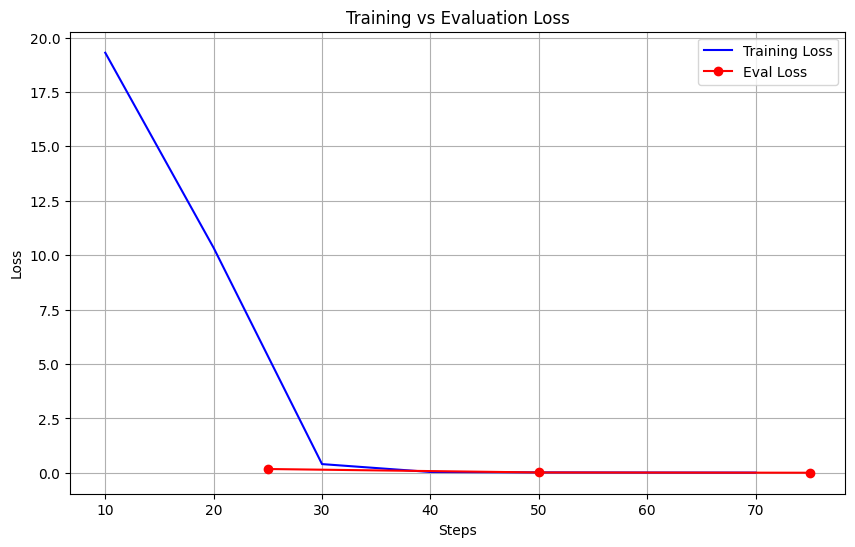

In [5]:

# Extract history
history = data['log_history']

# Separate training and evaluation logs
train_logs = [entry for entry in history if 'loss' in entry]
eval_logs = [entry for entry in history if 'eval_loss' in entry]

# Create DataFrames
df_train = pd.DataFrame(train_logs)
df_eval = pd.DataFrame(eval_logs)

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(df_train['step'], df_train['loss'], label='Training Loss', color='blue')
plt.plot(df_eval['step'], df_eval['eval_loss'], label='Eval Loss', marker='o', color='red')

plt.xlabel('Steps')
plt.ylabel('Loss')
plt.title('Training vs Evaluation Loss')
plt.legend()
plt.grid(True)
plt.show()